In [209]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import binom
pd.set_option('display.precision', 3)

In [142]:
df_names = ['T_w_reads_w2_w8.csv',
            'ICS_w_reads_w2_w8.csv',
            'K562_w_reads_w2_w8.csv',
            'U937_w_reads_w2_w8.csv',
            'Fly_w_reads_w2_w8.csv',
            'Shrimp-primary_w_reads_w2_w8.csv',
            'Tomato-Protoplasts_w_reads_w2_w8.csv',
            'Tomato-hairy-roots_eff.csv']
# df_names = ['DeepHF_final.csv']
concised_names=[]
for df_name in df_names:
    concised_names.append(df_name.split('_')[0])

In [3]:
# concised_names=[]
# for df_name in df_names:
#     concised_names.append(df_name.split('_')[0])

In [5]:
ics = pd.read_csv('/tamir2/shaicohen1/CRISPR_MAAGAD/CRISPR_review/code/final_feats/ICS_w_reads_w2_w8.csv')
all_feats = []

cai_and_chimera_cols = [f'{name}_{f}{m}_{win}'
        for win in [0,10,20] 
        for name,f in zip(['codon','aa','CAI','chimera'],['freqs_','freqs_','','']) 
        for m in ['avg','max']]

all_feats.extend(cai_and_chimera_cols)
tad = ['tad_density','tad_angle','tad_interactions']
orenstein = ['RRBS','H3K4me3','Dnase','CTCF']
isana = ['g_DNADNA','g_RNADNA','guideEne','guide&scafEne','clause','isBasePairs','Head1','Head2','Head3','1&2&3']
all_feats.extend(orenstein)
all_feats.extend(tad)
all_feats.extend(isana)
all_feats.extend([x for x in ics.columns.to_list() if 'DNAshape' in x])
all_feats.extend([x for x in ics.columns.to_list() if 'enthalpy' in x])
all_feats.extend([x for x in ics.columns.to_list() if 'LCC' in x])
all_feats.extend([x for x in ics.columns.to_list() if 'methylation' in x])
all_feats.extend([x for x in ics.columns.to_list() if 'conservation' in x])
all_feats.extend([x for x in ics.columns.to_list() if 'DNA_fold' in x])
all_feats.extend([x for x in ics.columns.to_list() if 'sites_count' in x])
all_feats.extend([x for x in ics.columns.to_list() if 'spacers' in x])
edit_eff_col = 'editing_efficiency'
corr_feats = pd.DataFrame({'feature':all_feats,'feat_appear_num':0})

In [4]:
# # df_names = ['DeepHF_final.csv','DeepCRISPR-hek293_final.csv',
# #             'DeepCRISPR-hela_final.csv','Leenay_final.csv'
          
# df_names = ['T_final_w_CRISP_2025_eff.csv',
#             'ICS_w_CRISP_2025_eff.csv',
#             'K562_w_CRISP_2025_eff.csv',
#             'U937_final_w_CRISP_2025_eff.csv',
#             'Fly_w_CRISP_2025_eff.csv',
#             'Shrimp-primary_final_w_CRISP_2025_eff.csv',
#             'Shrimp-embryos_final_w_CRISP_2025_eff.csv',
#             'Tomato-hairy-roots_eff.csv',
#             'Tomato-Protoplasts_eff.csv']
#             # 'BetterSeeds_w_CRISP_2025_eff.csv',
#             # 'Hazera_w_CRISP_2025_eff.csv',
#             # 'Rahan_w_CRISP_2025_eff.csv']

In [5]:
def merge_cells(cell1, cell2):
    if isinstance(cell1, list):
        return cell1 + [cell2]
    else:
        return [cell1, cell2]

# Filter similar features

In [769]:
new_df = pd.read_csv('ICS_w_CRISP_2025_eff.csv')

In [776]:
corr, p_value = stats.spearmanr(merged_df['editing_efficiency'],merged_df['eff_old'] )
print(corr)
print(p_value)

0.7231327467864923
4.741002863008446e-37


In [780]:
old_df.columns.to_list()

['g_rna_info',
 'RNA_minimum_free_energy',
 'RNA_ratio_of_paired_bases',
 'RNA_long_tail_len',
 'RNA_short_tail_len',
 'RNA_sum_len_of_tails',
 'RNA_G_C_paired_ratio',
 'RNA_A_U_paired_ratio',
 'k3-all_spacers-Q1',
 'k3-all_spacers-Q2',
 'k3-all_spacers-Q3',
 'k3-all_spacers-Q4',
 'k_3-all_spacers_cd95_cov100_log_freq_obs',
 'k3-Cas9_spacers-Q1',
 'k3-Cas9_spacers-Q2',
 'k3-Cas9_spacers-Q3',
 'k3-Cas9_spacers-Q4',
 'k_3-Cas9_spacers_cd95_cov100_log_freq_obs',
 'k3-Cas9a_spacers-Q1',
 'k3-Cas9a_spacers-Q2',
 'k3-Cas9a_spacers-Q3',
 'k3-Cas9a_spacers-Q4',
 'k_3-Cas9a_spacers_cd95_cov100_log_freq_obs',
 'k3-Cas9a_spy_like_cluster_spacers-Q1',
 'k3-Cas9a_spy_like_cluster_spacers-Q2',
 'k3-Cas9a_spy_like_cluster_spacers-Q3',
 'k3-Cas9a_spy_like_cluster_spacers-Q4',
 'k_3-Cas9a_spy_cluster_cd90_cov80_spacers_cd95_cov100_log_freq_obs',
 'k3-Cas9a_spy_cluster_spacers-Q1',
 'k3-Cas9a_spy_cluster_spacers-Q2',
 'k3-Cas9a_spy_cluster_spacers-Q3',
 'k3-Cas9a_spy_cluster_spacers-Q4',
 'k_3-Cas9a_spy

In [807]:
merged_df = new_df.merge(old_df[['g_rna_info', 'eff_old','old_target_seq']], on='g_rna_info', how='left')
print(np.all(merged_df['target_seq']==merged_df['old_target_seq']))
merged_df[['g_rna_info','eff_old','editing_efficiency','target_seq','old_target_seq']].iloc[4:6,:]

True


,g_rna_info,eff_old,editing_efficiency,target_seq,old_target_seq
4,9_5534893_5534913_-,74.518,91.11,AAAGTGGCTCTTTCACGGTGTGG,AAAGTGGCTCTTTCACGGTGTGG
5,17_40016574_40016594_-,91.540,91.19,AGCTGCAGTGTGTCCAAGGTGGG,AGCTGCAGTGTGTCCAAGGTGGG


In [796]:
old_eff = pd.read_csv('ICS_eff.tsv',sep='\t')

In [809]:
# old_eff[old_eff.cut_site==6562738+17]
old_eff[old_eff.cut_site==40016574+3]

,sqa,member,cell_type,g_rna_id,nuclease,round,editing_efficiency,num_reads,percent_align,member_code,genome,chr,cut_site,strand,enzyme,eff_zscore
89,SQA#0001796,Pluristem,ICS,PLS:1:23:1:1:Human_hg38:17:40016577:-:Cas9,Cas9,Round 4,91.54,32510.0,96.54,PLS,Human_hg38,17,40016577,-,Cas9,0.358


In [770]:
old_df = pd.read_csv('ICS_feats.tsv',sep='\t')
old_df=old_df.rename(columns={'Unnamed: 0':'g_rna_info','editing_efficiency':'eff_old'})

In [789]:
cols = [f'sgRNA_seq_{i}_char' for i in range(23)]
old_df['old_target_seq'] = old_df[cols].astype(str).agg(''.join, axis=1)

In [773]:
old_df[['g_rna_info','eff_old']]

,g_rna_info,eff_old
0,8_6562738_6562758_+,95.971
1,15_39582304_39582324_-,51.017
2,11_64320867_64320887_+,93.267
3,1_198638846_198638866_+,59.718
4,9_5534893_5534913_-,74.518
...,...,...
239,14_61720543_61720563_+,88.247
240,12_100510971_100510991_+,93.824
241,1_206769851_206769871_-,83.043
242,6_31507388_31507408_+,93.965


In [6]:
def make_rep_feats(df,edit_eff_name):
    feats_to_keep = []
    cai_and_chimera_cols = [f'{name}_{f}{m}_{win}'
        for win in [0] 
        for name,f in zip(['codon','aa','CAI','chimera'],['freqs_','freqs_','','']) 
        for m in ['avg']]
    # tad = ['tad_density','tad_angle','tad_interactions']
    # feats_to_keep.extend(tad)
    # orenstein = ['RRBS','H3K4me3','Dnase','CTCF']
    # feats_to_keep.extend(orenstein)
    isana = ['g_DNADNA','g_RNADNA','guideEne','guide&scafEne','clause','isBasePairs','Head1','Head2','Head3','1&2&3']
    feats_to_keep.extend(cai_and_chimera_cols)
    feats_to_keep.extend(isana)
    feats_to_keep.extend([x for x in df.columns.to_list() if 'DNAshape' in x 
                  and 'mean' in x and 'ext' not in x])
    feats_to_keep.extend([x for x in df.columns.to_list() if 'enthalpy' in x
                      and 'mean' in x and 'ext' not in x])
    LCC_feats = [x for x in df.columns.to_list() if 'LCC' in x]
    df.loc[:,'LCC_rep'] = df[LCC_feats].mean(axis=1)
    feats_to_keep.append('LCC_rep')
    feats_to_keep.extend([x for x in df.columns.to_list() if 'methylation' in x
                      and 'mean' in x and 'ext' not in x])
    sites_feats = [x for x in df.columns.to_list() if 'sites_count' in x
     and (x[-2:] in '-0-5' or x[-2:] in 'd0d2d5')
     and 'orf' not in x and 'full' not in x and 'global' not in x
     and(('ngg_pam_1000_' in x or 'count_1000_' in x)
     or ('ngg_pam_10000_' in x or 'count_10000_' in x)
     or ('ngg_pam_100000_' in x or 'count_100000_' in x)
     or ('ngg_pam_100000_' in x or 'count_100000_' in x))]
    sites_feats.extend(['sites_count_ngg_pam_genome_-10_d0','sites_count_ngg_pam_genome_-10_d2','sites_count_ngg_pam_genome_-10_d5'])
    feats_to_keep.extend(sites_feats)
    df.loc[:,'k5_Q1_rep'] = df[[x for x in df.columns.to_list() if 'spacers' in x
    and 'Q1' in x and 'k5' in x and 'GCvsAT' not in x]].mean(axis=1)
    df.loc[:,'k5_Q4_rep'] = df[[x for x in df.columns.to_list() if 'spacers' in x
    and 'Q4' in x and 'k5' in x and 'GCvsAT' not in x]].mean(axis=1)
    feats_to_keep.extend(['k5_Q1_rep','k5_Q4_rep'])
    feats_to_keep.append(edit_eff_name)
    return df[feats_to_keep]

In [7]:
ics = pd.read_csv('/tamir2/shaicohen1/CRISPR_MAAGAD/CRISPR_review/code/final_feats/ICS_w_CRISP_2025_eff.csv')
df = make_rep_feats(ics)
all_feats = df.columns.to_list()
all_feats=all_feats[:-1]
all_feats
edit_eff_col = 'editing_efficiency'
corr_feats = pd.DataFrame({'feature':all_feats,'feat_appear_num':0})

TypeError: make_rep_feats() missing 1 required positional argument: 'edit_eff_name'

# Pairwise

In [ ]:
def to_float(x):
    try:
        return float(x)
    except:
        return float('nan')

In [24]:
ics.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'g_rna_info',
       'RNA_minimum_free_energy', 'RNA_ratio_of_paired_bases',
       'RNA_long_tail_len', 'RNA_short_tail_len', 'RNA_sum_len_of_tails',
       'RNA_G_C_paired_ratio',
       ...
       'editing_efficinecy_10_9_25', 'reads_processed_18_9_25',
       'reads_aligned_18_9_25', 'raw_18_9_25_edit',
       'editing_efficinecy_w8_no_subs_18_9_25', 'reads_processed_23_9_25',
       'reads_aligned_23_9_25', 'perc_aligned_23_9_25', 'raw_23_9_25_edit',
       'editing_efficinecy_w2_no_subs_23_9_25'],
      dtype='object', length=858)

In [164]:
def gen_pairwise_graphs(df_names, significant_feats_df,nice_names):
    perc_mult=0.3

    order = [x.split('_')[0] for x in df_names]
    concised_names = []
    results = {}
    feats_to_show = []
    for df_name in df_names:
        print(df_name)
        df = pd.read_csv(df_name)
        editing_efficiency='editing_efficinecy_w8_no_subs_18_9_25'
        if df_name == 'Tomato-hairy-roots_eff.csv':
            editing_efficiency = 'editing_efficiency'
        for to_rand in ['']:#['','rand']:
            df = df[~df[editing_efficiency].isna()]
            df = make_rep_feats(df,editing_efficiency)
            concised_name = df_name.split('_')[0].replace('Shrimp','Prawn').replace("ICS",'PLX')
            concised_names.append(concised_name)
            df[editing_efficiency] = pd.to_numeric(df[editing_efficiency], errors='coerce')
            # if to_rand=='rand':
            #         df[editing_efficiency] = df[editing_efficiency].sample(frac=1, random_state=123).reset_index(drop=True)
            # else:
            #     print('------no randomiztion-------')
    
            #sort df according to editing eff
            df = df.sort_values(by=editing_efficiency)
            feats_to_show = [v.split(';')[0] for v in significant_feats_df.loc[significant_feats_df['name'] == df_name.split('_')[0], [f'feat_{i}' for i in range(1, 9)]].values.flatten() if pd.notna(v)]
            print(feats_to_show)
            for col in feats_to_show:
                # print(col)
                mask = df[col].notna() & pd.to_numeric(df[col], errors='coerce').isna()
                mask = ~mask
                if mask.sum()==0:
                    print('da fuck')
                    continue
                idx_cutoff = round(len(df)*perc_mult)
                top_vals = pd.to_numeric(df.iloc[:idx_cutoff, df.columns.get_loc(col)], errors='coerce').reset_index(drop=True)
                bottom_vals = pd.to_numeric(df.iloc[-idx_cutoff:, df.columns.get_loc(col)], errors='coerce').reset_index(drop=True)
                # Align lengths if needed (if idx_cutoff counts exact rows)
                length = min(len(top_vals), len(bottom_vals))
                top_vals = top_vals[:length]
                bottom_vals = bottom_vals[:length]
                # Create mask to keep only pairs with no NaN
                mask = ~(top_vals.isna() | bottom_vals.isna())
                if to_rand=='rand':
                    final_top_30_rand = top_vals[mask]
                    final_bottom_30_rand = bottom_vals[mask]
                else:
                    final_top_30 = top_vals[mask]
                    final_bottom_30 = bottom_vals[mask]
                final_top_30 = np.ravel(final_top_30).tolist()
                final_bottom_30 = np.ravel(final_bottom_30).tolist()
                df_30 = pd.DataFrame({
                    f"{col} Value": final_top_30 + final_bottom_30,
                    "Group": (["Top 30"] * len(final_top_30) +
                              ["Bottom 30"] * len(final_bottom_30))})       
                plt.figure(figsize=(8, 5))
                # sns.boxplot(data=df_30, x="Group", y="Value", palette=["#2E8B57", "#CD5C5C", "#90EE90", "#F08080"])
                sns.boxplot(data=df_30, x="Group", y=f"{col} Value", palette=["#2E8B57", "#CD5C5C"])
                plt.title(f"Cell {concised_name}, Top 30% vs Bottom 30% of feature: '{col}'")
                plt.ylabel(nice_names[col])
                plt.show()
        #     break
        # break
    # break
                # stat, p_value = mannwhitneyu(x, y, alternative='greater')
    # return feats_to_show

In [165]:
significant_feats_df = pd.read_excel('raw_Significant_feats_Table_S9.xlsx')

In [168]:
significant_feats_df

,name,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8
0,T,guide&scafEne;p=0.0008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ICS,sites_count_ngg_pam_genome_-10_d5;p=0.0008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,K562,codon_freqs_avg_0;p=0.0008,aa_freqs_avg_0;p=0.0008,CAI_avg_0;p=0.0008,chimera_avg_0;p=0.0008,g_RNADNA;p=0.0008,guide&scafEne;p=0.0008,Head2;p=0.0008,local_sites_count_ngg_pam_10000_-0;p=0.0008
3,U937,aa_freqs_avg_0;p=0.0008,Head1;p=0.0008,Head2;p=0.0008,1&2&3;p=0.0008,DNAshape_MGW_mean;p=0.0008,DNAshape_Roll_mean;p=0.0008,local_sites_count_10000_-5;p=0.0008,local_sites_count_ngg_pam_100000_-5;p=0.0008
4,Fly,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Shrimp-primary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Tomato-Protoplasts,local_sites_count_ngg_pam_1000_-5;p=0.0008,local_sites_count_1000_-5;p=0.0008,NaN,NaN,NaN,NaN,NaN,NaN
7,Tomato-Hairy roots,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [214]:
df_names

['T_w_reads_w2_w8.csv',
 'ICS_w_reads_w2_w8.csv',
 'K562_w_reads_w2_w8.csv',
 'U937_w_reads_w2_w8.csv',
 'Fly_w_reads_w2_w8.csv',
 'Shrimp-primary_w_reads_w2_w8.csv',
 'Tomato-Protoplasts_w_reads_w2_w8.csv',
 'Tomato-hairy-roots_eff.csv']

In [273]:
import matplotlib.ticker as mticker

def thousands_formatter(x, pos):
    return f'{x:.1e}'
    # return f'{int(x/1000)}K' if x >= 1000 else f'{int(x)}'

In [298]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def gen_pairwise_graphs(df_names, significant_feats_df, nice_names):
    perc_mult = 0.3
    order = [x.split('_')[0] for x in df_names]
    concised_names = []
    results = {}
    feats_to_show = []
    all_dfs = []  # for counting total plots

    # First, gather all feature names to know how many subplots we’ll need
    for df_name in df_names:
        feats = [v.split(';')[0] for v in significant_feats_df.loc[
            significant_feats_df['name'] == df_name.split('_')[0],
            [f'feat_{i}' for i in range(1, 9)]
        ].values.flatten() if pd.notna(v)]
        for col in feats:
            all_dfs.append((df_name, col))

    n_plots = len(all_dfs)
    n_cols = 4  # adjust based on desired grid width
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()

    plot_idx = 0
    for df_name in df_names:
        # print(df_name)        
        editing_efficiency = 'editing_efficinecy_w8_no_subs_18_9_25'

        if df_name == 'Tomato-hairy-roots_eff.csv':
            editing_efficiency = 'editing_efficiency'
            # continue
            
        df = pd.read_csv(df_name)


        df = df[~df[editing_efficiency].isna()]
        df = make_rep_feats(df, editing_efficiency)
        concised_name = df_name.split('_')[0].replace('Shrimp-primary', 'Prawn').replace("ICS", 'PLX').replace('Tomato-Protoplasts','Tomato leaf')
        # print('concised', concised_name)
        concised_names.append(concised_name)
        df[editing_efficiency] = pd.to_numeric(df[editing_efficiency], errors='coerce')
        df = df.sort_values(by=editing_efficiency)

        feats_to_show = [v.split(';')[0] for v in significant_feats_df.loc[
            significant_feats_df['name'] == df_name.split('_')[0],
            [f'feat_{i}' for i in range(1, 9)]
        ].values.flatten() if pd.notna(v)]

        for col in feats_to_show:
            mask = df[col].notna() & pd.to_numeric(df[col], errors='coerce').isna()
            mask = ~mask
            if mask.sum() == 0:
                continue
            idx_cutoff = round(len(df) * perc_mult)
            top_vals = pd.to_numeric(df.iloc[:idx_cutoff, df.columns.get_loc(col)], errors='coerce').reset_index(drop=True)
            bottom_vals = pd.to_numeric(df.iloc[-idx_cutoff:, df.columns.get_loc(col)], errors='coerce').reset_index(drop=True)

            length = min(len(top_vals), len(bottom_vals))
            top_vals = top_vals[:length]
            bottom_vals = bottom_vals[:length]
            mask = ~(top_vals.isna() | bottom_vals.isna())

            final_top_30 = np.ravel(top_vals[mask]).tolist()
            final_bottom_30 = np.ravel(bottom_vals[mask]).tolist()

            df_30 = pd.DataFrame({
                "Value": final_top_30 + final_bottom_30,
                "Group": (["Top 30"] * len(final_top_30) + ["Bottom 30"] * len(final_bottom_30))
            })

            ax = axes[plot_idx]
            sns.boxplot(data=df_30, x="Group", y="Value", palette=["#2E8B57", "#CD5C5C"], ax=ax)
            if col=='sites_count_ngg_pam_genome_-10_d5' and concised_name=='PLX':
                ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands_formatter))
                # ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
                # ax.set_ylabel(nice_names.get(col, col) + " (×1e6)", fontsize=14)
                
                # # Hide offset text entirely
                # ax.yaxis.get_offset_text().set_visible(False)
            if len(col)>32:
                font_for_title = 13
            else:
                font_for_title = 16
            # print(f"{concised_name}: {col}")
            ax.set_title(f"{concised_name}: {col}", fontsize=font_for_title,fontweight='bold')
            ax.set_ylabel(nice_names.get(col, col),fontsize=16)
            ax.tick_params(axis='x', rotation=30,labelsize=16)
            # ax.ticklabel_format(style='plain', axis='y')
            # Remove x-axis label ("Group")
            ax.set_xlabel("")
            plot_idx += 1

    # Hide any unused axes
    for i in range(plot_idx, len(axes)):
        fig.delaxes(axes[i])

    fig.suptitle("Top vs Bottom 30% significant features", fontsize=20,fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    fig.subplots_adjust(wspace=0.45) 
    plt.savefig('Signicant_feats_10_12_25.svg', format="svg")
    plt.show()


In [299]:
nice_names={'1&2&3':'Existence of\n3 stem loops in scaffold',
 'CAI_avg_0': 'CAI',
 'DNAshape_MGW_mean': 'Mean\nMinimal Groove Width (DNAshape)',
 'DNAshape_Roll_mean': 'Mean Roll (DNAshape)',
 'Head1': 'Existence of 1st\nstemp loop in scaffold',
 'Head2': 'Existence of 2nd\nstemp loop in scaffold',
 'aa_freqs_avg_0': 'Frequent AA index',
 'chimera_avg_0': 'Chimera index',
 'codon_freqs_avg_0': 'Frequent codon index',
 'g_RNADNA': 'melting temperature\nof spacer with site in genome',
 'guide&scafEne': 'Minimum free energy\n of scaffold & guide',
 'local_sites_count_10000_-5': '# of local sites\n(PAM=False,dist=10K,\nsuffix_len=5)',
 'local_sites_count_1000_-5': '# of local sites\n(PAM=False,dist=1K,\nsuffix_len=5)',
 'local_sites_count_ngg_pam_100000_-5': '# of sites\n(PAM_adj=True,dist=100K,\nsuffix_len=5)',
 'local_sites_count_ngg_pam_10000_-0': '# of sites\n(PAM_adj=True,dist=10K,\nsuffix_len=0)',
 'local_sites_count_ngg_pam_1000_-5': '# of sites\n(PAM_adj=True,dist=1K,\nsuffix_len=5)',
 'sites_count_ngg_pam_genome_-10_d5': '# of sites\n(PAM_adj=True,dist=inf,\nsuffix_len=5)'}

/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_36052/254454882.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_30, x="Group", y="Value", palette=["#2E8B57", "#CD5C5C"], ax=ax)
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_36052/254454882.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_30, x="Group", y="Value", palette=["#2E8B57", "#CD5C5C"], ax=ax)
/var/tmp/pbs.5461973.power9.tau.ac.il/ipykernel_36052/254454882.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_30, x="Group", y="Value", palette=["#2E8B5

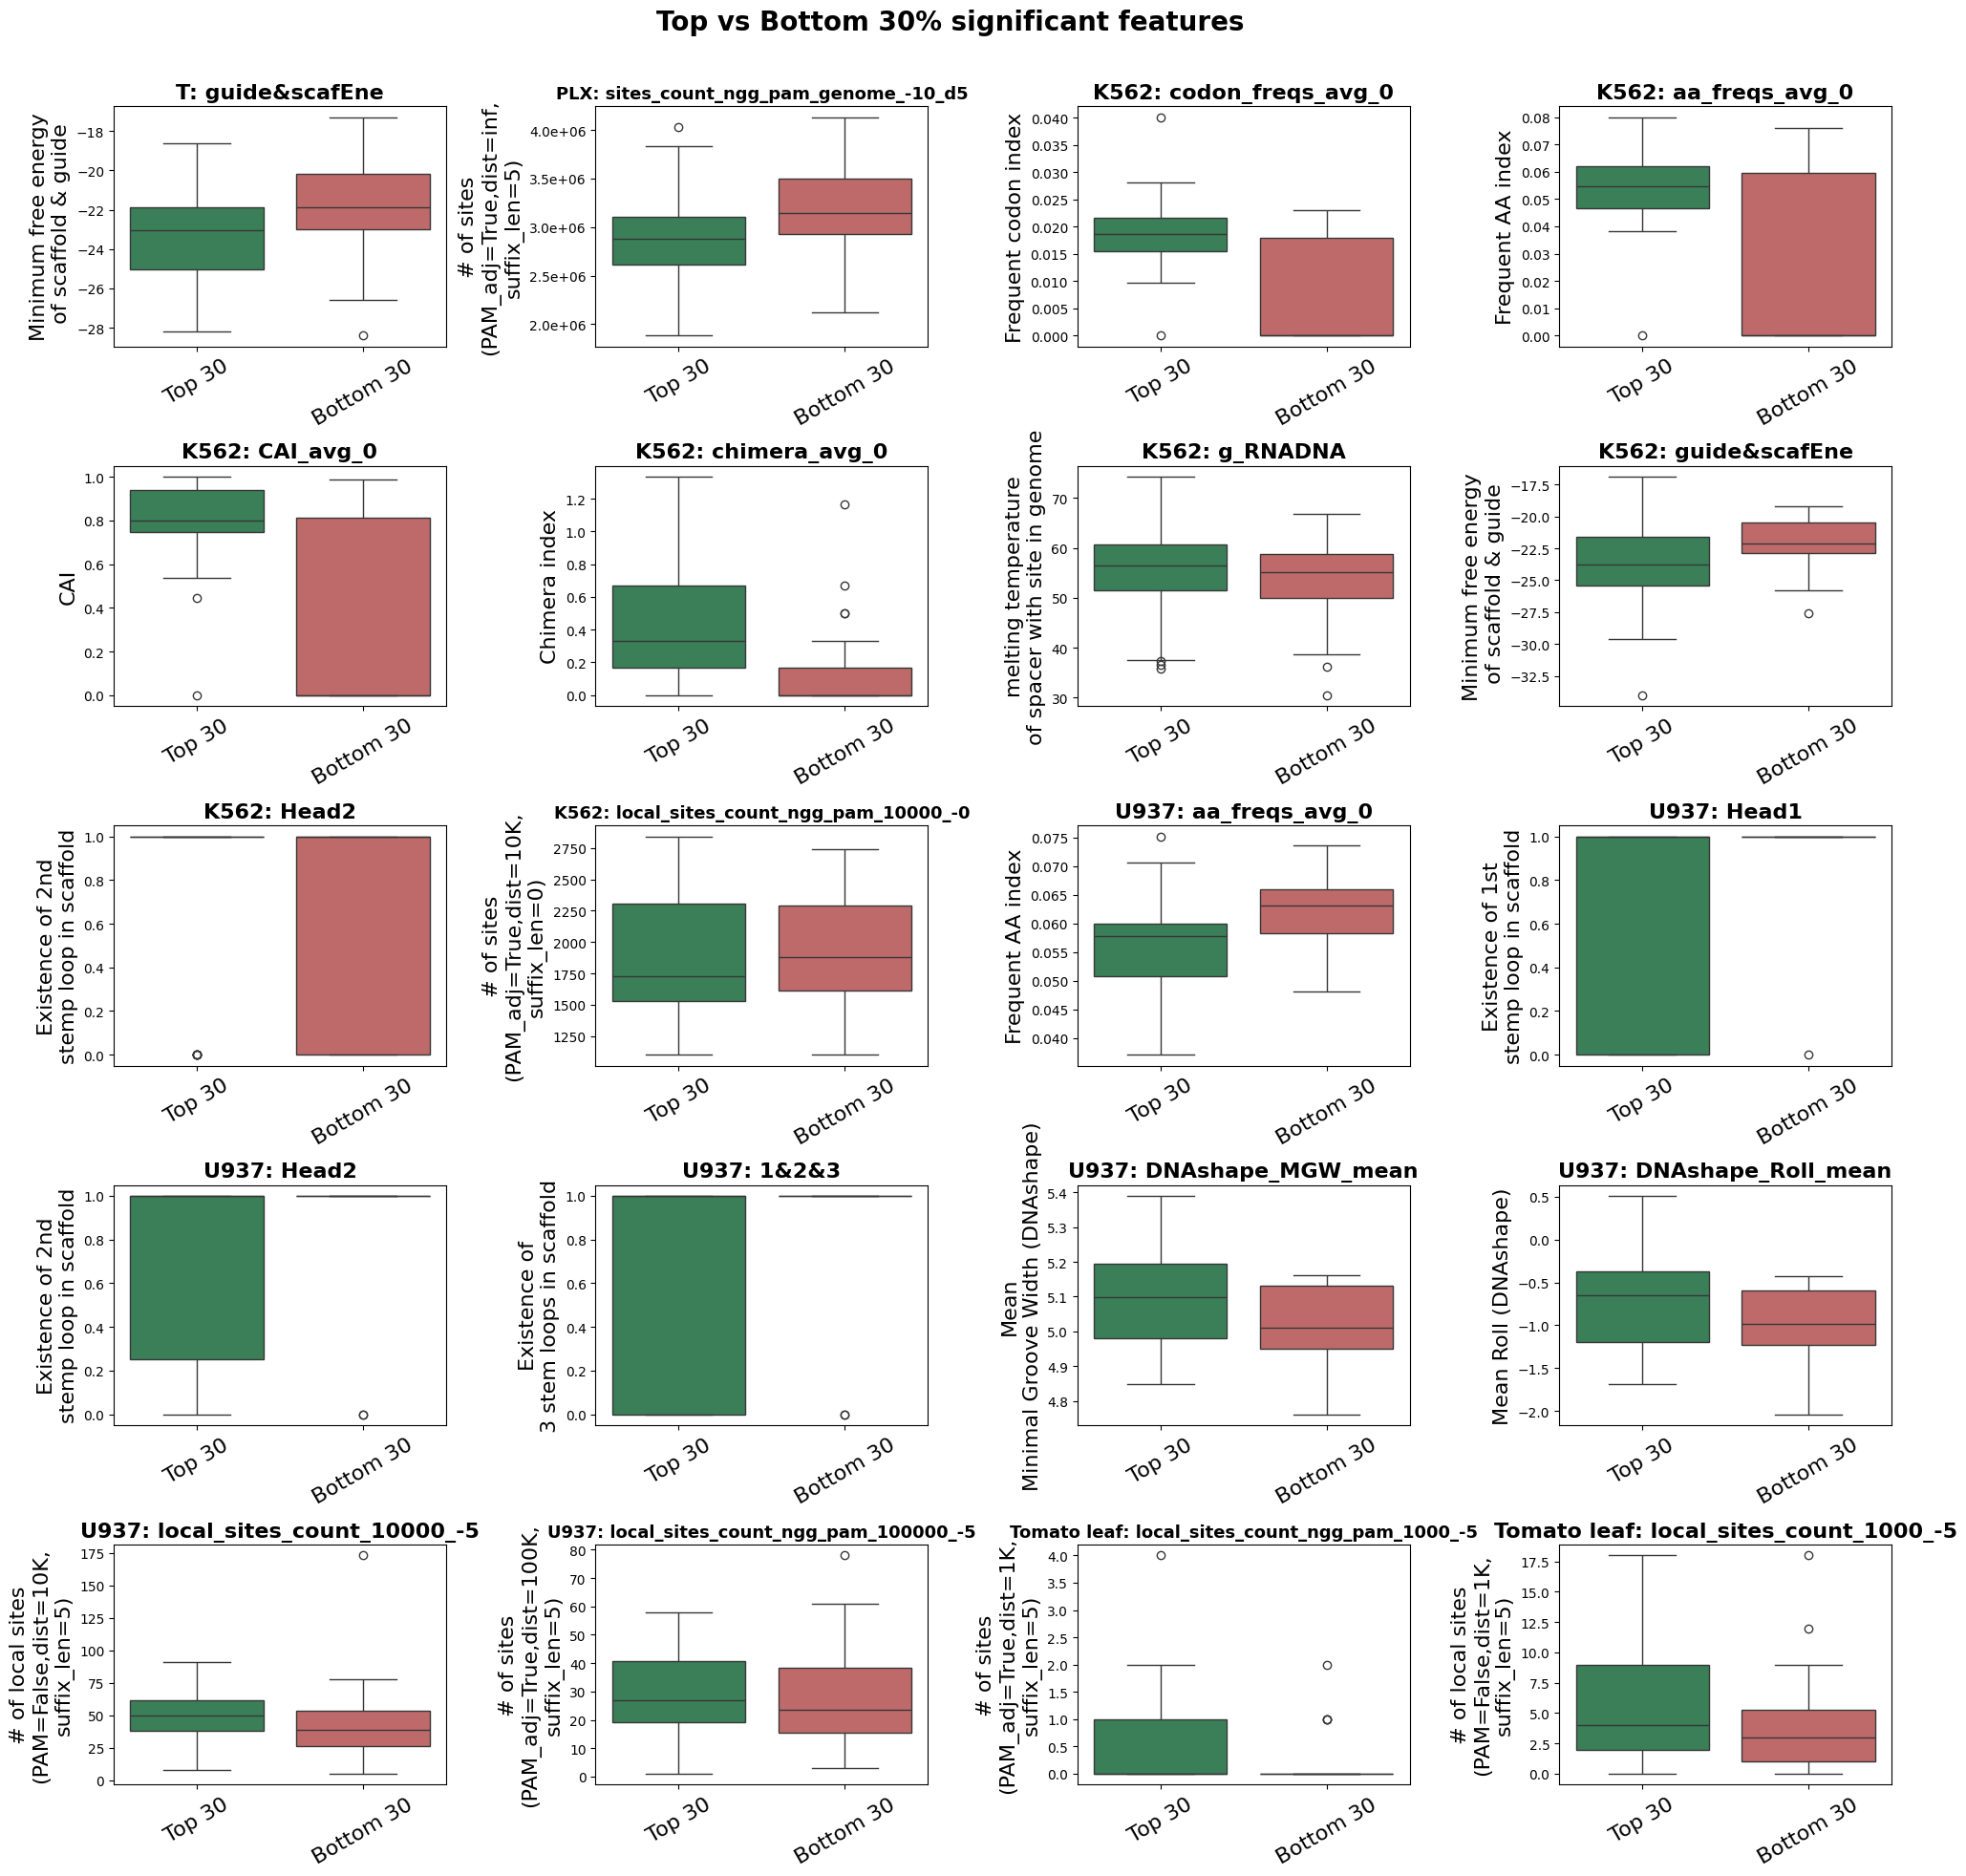

In [300]:
gen_pairwise_graphs(df_names, significant_feats_df,nice_names)

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def gen_pairwise_graphs(df_names, significant_feats_df, nice_names):
    perc_mult = 0.3
    order = [x.split('_')[0] for x in df_names]
    concised_names = []
    results = {}
    feats_to_show = []
    all_dfs = []  # for counting total plots

    # First, gather all feature names to know how many subplots we’ll need
    for df_name in df_names:
        feats = [v.split(';')[0] for v in significant_feats_df.loc[
            significant_feats_df['name'] == df_name.split('_')[0],
            [f'feat_{i}' for i in range(1, 9)]
        ].values.flatten() if pd.notna(v)]
        for col in feats:
            all_dfs.append((df_name, col))

    n_plots = len(all_dfs)
    n_cols = 4  # adjust based on desired grid width
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()

    plot_idx = 0
    for df_name in df_names:
        # print(df_name)
        df = pd.read_csv(df_name)
        editing_efficiency = 'editing_efficinecy_w8_no_subs_18_9_25'
        if df_name == 'Tomato-hairy-roots_eff.csv':
            editing_efficiency = 'editing_efficiency'

        df = df[~df[editing_efficiency].isna()]
        df = make_rep_feats(df, editing_efficiency)
        concised_name = df_name.split('_')[0].replace('Shrimp', 'Prawn').replace("ICS", 'PLX')
        concised_names.append(concised_name)
        df[editing_efficiency] = pd.to_numeric(df[editing_efficiency], errors='coerce')
        df = df.sort_values(by=editing_efficiency)

        feats_to_show = [v.split(';')[0] for v in significant_feats_df.loc[
            significant_feats_df['name'] == df_name.split('_')[0],
            [f'feat_{i}' for i in range(1, 9)]
        ].values.flatten() if pd.notna(v)]

        for col in feats_to_show:
            mask = df[col].notna() & pd.to_numeric(df[col], errors='coerce').isna()
            mask = ~mask
            if mask.sum() == 0:
                continue
            idx_cutoff = round(len(df) * perc_mult)
            top_vals = pd.to_numeric(df.iloc[:idx_cutoff, df.columns.get_loc(col)], errors='coerce').reset_index(drop=True)
            bottom_vals = pd.to_numeric(df.iloc[-idx_cutoff:, df.columns.get_loc(col)], errors='coerce').reset_index(drop=True)

            length = min(len(top_vals), len(bottom_vals))
            top_vals = top_vals[:length]
            bottom_vals = bottom_vals[:length]
            mask = ~(top_vals.isna() | bottom_vals.isna())

            final_top_30 = np.ravel(top_vals[mask]).tolist()
            final_bottom_30 = np.ravel(bottom_vals[mask]).tolist()

            df_30 = pd.DataFrame({
                "Value": final_top_30 + final_bottom_30,
                "Group": (["Top 30"] * len(final_top_30) + ["Bottom 30"] * len(final_bottom_30))
            })

            ax = axes[plot_idx]
            sns.boxplot(data=df_30, x="Group", y="Value", palette=["#2E8B57", "#CD5C5C"], ax=ax)
            ax.set_title(f"{concised_name}: {col}", fontsize=16,fontweight='bold')
            ax.set_ylabel(nice_names.get(col, col),fontsize=14)
            ax.tick_params(axis='x', rotation=30,labelsize=14)
            # Remove x-axis label ("Group")
            ax.set_xlabel("")
            plot_idx += 1

    # Hide any unused axes
    for i in range(plot_idx, len(axes)):
        fig.delaxes(axes[i])

    fig.suptitle("Top vs Bottom 30% Feature Distributions", fontsize=20,fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    # plt.savefig('Signicant_feats.svg', format="svg")
    plt.show()


In [56]:
# # print(len(final_top_30), len(final_bottom_30), len(final_top_30_rand), len(final_bottom_30_rand))
# # Ensure flat lists
# final_top_30 = np.ravel(final_top_30).tolist()
# final_bottom_30 = np.ravel(final_bottom_30).tolist()
# # final_top_30_rand = np.ravel(final_top_30_rand).tolist()
# # final_bottom_30_rand = np.ravel(final_bottom_30_rand).tolist()

# # # Build DataFrame
# # df_30 = pd.DataFrame({
# #     "Value": final_top_30 + final_bottom_30 + final_top_30_rand + final_bottom_30_rand,
# #     "Group": (["Top 30"] * len(final_top_30) +
# #               ["Bottom 30"] * len(final_bottom_30) +
# #               ["Top 30 (randomized)"] * len(final_top_30_rand) +
# #               ["Bottom 30 (randomized)"] * len(final_bottom_30_rand))
# # })
# df_30 = pd.DataFrame({
#     "Value": final_top_30 + final_bottom_30,
#     "Group": (["Top 30"] * len(final_top_30) +
#               ["Bottom 30"] * len(final_bottom_30))})

# # Plot # option 1
# # plt.figure(figsize=(8, 5))
# # sns.stripplot(data=df_30, x="Group", y="Value", jitter=True,
# #               palette=["#2E8B57", "#CD5C5C", "#90EE90", "#F08080"])
# # plt.title("Distribution of Top vs Bottom 30 (Original vs Randomized)")
# # plt.show()

# # # Plot # option 2
# # means = [np.mean(final_top_30), np.mean(final_bottom_30),
# #  np.mean(final_top_30_rand), np.mean(final_bottom_30_rand)]

# # labels = ["Top 30", "Bottom 30", "Top 30 (rand)", "Bottom 30 (rand)"]
# # colors = ["#2E8B57", "#CD5C5C", "#90EE90", "#F08080"]

# # plt.figure(figsize=(8, 5))
# # bars = plt.bar(labels, means, color=colors)
# # plt.ylabel("Mean value")
# # plt.title("Mean of top vs bottom 30 (original vs randomized)")
# # # plt.tight_layout()
# # plt.show()

# plt.figure(figsize=(8, 5))
# # sns.boxplot(data=df_30, x="Group", y="Value", palette=["#2E8B57", "#CD5C5C", "#90EE90", "#F08080"])
# sns.boxplot(data=df_30, x="Group", y=f"{} Value", palette=["#2E8B57", "#CD5C5C"])
# plt.title("Top vs Bottom 30 distributions (original vs randomized)")
# plt.show()
# break
#         # stat, p_value = mannwhitneyu(x, y, alternative='greater')

In [28]:
df = pd.read_csv(df_names[0])

In [31]:
len(df[~df['editing_efficinecy_w8_no_subs_18_9_25'].isna()])*.3

36.3

In [25]:
def calc_pairwise(rand_i, df_names, all_feats,rand_way='sample',make_rep=False, perc_mult=0.5,public='',old=''):
    # editing_efficiency = old + 'editing_efficiency'
    # editing_efficiency = 'editing_efficinecy_10_9_25'
    # editing_efficinecy_w8_no_subs_18_9_25
    editing_efficiency = 'editing_efficinecy_w2_no_subs_23_9_25'
    order = [x.split('_')[0] for x in df_names]
    # order = order+['p_' + x.split('_')[0] for x in df_names]
    order = ['feature'] + order
    concised_names = []
    corr_feats = pd.DataFrame({'feature':all_feats,'feat_appear_num':0})
    make_rep_str = ''
    if make_rep:
        make_rep_str = 'make_rep_A'
    for df_name in df_names:
        # print(df_name)
        cols_to_float=[]
        if df_name == 'Leenay_final.csv':
            cols_to_float = [484,485,486,487,488,489,490,491,492,493,494,495,695,696,697,698,699,700,701,702,703,704,705,706,496,497,764,765,766,767,768,769,770,771,772,773,774,775]
        elif df_name == 'DeepHF_final.csv':
            cols_to_float = [486,487,488,489,490,491,492,493,494,495,496,497,764,765,766,767,768,769,770,771,772,773,774,775]
        if cols_to_float:
            df = pd.read_csv(df_name, converters={col: to_float for col in cols_to_float})
        else:
            df = pd.read_csv(df_name)
        df = df[~df[editing_efficiency].isna()]
        if make_rep:
            df = make_rep_feats(df,editing_efficiency)
        concised_name = df_name.split('_')[0]
        concised_names.append(concised_name)
        corr_feats.loc[:,concised_name] = np.nan
        columns_to_check = [x for x in df.columns if x in all_feats]
        corr_feats.loc[corr_feats['feature'].isin(columns_to_check), 'feat_appear_num'] += 1
        # columns_to_check = [x for x in columns_to_check if len([y for y in cols_to_drop if y in x])==0]
        results=[]
        const_feats = []
        df[editing_efficiency] = pd.to_numeric(df[editing_efficiency], errors='coerce')
        if rand_i != 0:
            # print(df['editing_efficiency'].iloc[:10])
            if rand_way=='sample':
                df[editing_efficiency] = df[editing_efficiency].sample(frac=1, random_state=rand_i).reset_index(drop=True)
            elif rand_way=='numpy':
                np.random.seed(rand_i)
                df[editing_efficiency] = np.random.permutation(df[editing_efficiency])
            # print(df['editing_efficiency'].iloc[:10])
        else:
            print('------no randomiztion-------')

        #sort df according to editing eff
        df = df.sort_values(by=editing_efficiency)
        for col in columns_to_check:
            mask = df[col].notna() & pd.to_numeric(df[col], errors='coerce').isna()
            mask = ~mask
            if mask.sum()==0:
                # print(col)
                continue
            if len(df[col].unique()) > 1:  # Check if column has more than one unique valuedf]
                # p is small when value of feature is bigger in
                # top 50% efficiencies than in bottom 50%.
                # NOTE - bigger is just a number so each feature needs to
                # checked if the bigger it is the more likely it is to be associated with higher eff.
                idx_cutoff = round(len(df)*perc_mult)
                
                # stat, p_value = mannwhitneyu(pd.to_numeric(df.loc[:idx_cutoff,col], errors='coerce'),
                #                    pd.to_numeric(df.loc[len(df)-idx_cutoff:,col], errors='coerce'),
                #                    alternative='greater')
                top_vals = pd.to_numeric(df.iloc[:idx_cutoff, df.columns.get_loc(col)], errors='coerce').reset_index(drop=True)
                bottom_vals = pd.to_numeric(df.iloc[-idx_cutoff:, df.columns.get_loc(col)], errors='coerce').reset_index(drop=True)
                
                # Align lengths if needed (if idx_cutoff counts exact rows)
                length = min(len(top_vals), len(bottom_vals))
                top_vals = top_vals[:length]
                bottom_vals = bottom_vals[:length]
                
                # Create mask to keep only pairs with no NaN
                mask = ~(top_vals.isna() | bottom_vals.isna())
                
                x = top_vals[mask]
                y = bottom_vals[mask]
                # if any(~mask):
                #     print(sum(x for x in ~mask), col)
                stat, p_value = mannwhitneyu(x, y, alternative='greater')
                # print('stat:', stat)
                if np.isnan(p_value):
                    print(f'{col} bad')
                    # print(pd.to_numeric(df.loc[:5,col], errors='coerce'))
                    # print(pd.to_numeric(df.loc[len(df)-5:,col], errors='coerce'))
                else:
                    results.append((col, p_value))
            else:
                const_feats.append([col,concised_name])    
        # Convert results to a DataFrame
        results_df = pd.DataFrame(results, columns=['feature', 'p_value'])
        # Merge the two DataFrames on the 'feature' column
        merged_df = corr_feats.merge(results_df[['feature','p_value']], on='feature', how='left')
        # Update the 'A' column with 'p_value' from the merged DataFrame where 'feature' matches
        corr_feats[concised_name] = merged_df['p_value']
        # corr_feats['p_' + concised_name] = np.nan
    order+=['feat_appear_num']
    corr_feats = corr_feats[order]
    df = corr_feats[corr_feats[concised_names].notna().all(axis=1)].copy()
    df.to_csv(f'./wilcoxon_dfs/{public}{int(100*perc_mult)}_v_{int(100*perc_mult)}/df_{old}_edit_{rand_way}_{int(100*perc_mult)}_v_{int(100*perc_mult)}_{make_rep_str}_{rand_i}.csv',index=False)

In [815]:
# rand_i=42
# a = pd.read_csv(f'./wilcoxon_dfs/{public}{int(100*perc_mult)}_v_{int(100*perc_mult)}/df_sample_{int(100*perc_mult)}_v_{int(100*perc_mult)}_make_rep_A_{rand_i}.csv')
# a.iloc[6,[0,6]]
# df = pd.read_csv('Shrimp-primary_final_w_CRISP_2025_eff.csv')
# rand_i=42
# col='guideEne'
# rand_way='sample'
# df['editing_efficiency'] = pd.to_numeric(df['editing_efficiency'], errors='coerce')
# if rand_i != 0:
#     # print(df['editing_efficiency'].iloc[:10])
#     if rand_way=='sample':
#         df['editing_efficiency'] = df['editing_efficiency'].sample(frac=1, random_state=rand_i).reset_index(drop=True)
#     elif rand_way=='numpy':
#         np.random.seed(rand_i)
#         df['editing_efficiency'] = np.random.permutation(df['editing_efficiency'])
#     # print(df['editing_efficiency'].iloc[:10])
# else:
#     print('------no randomiztion-------')

# #sort df according to editing eff
# df = df.sort_values(by='editing_efficiency')
# idx_cutoff = round(len(df)*perc_mult)
# # stat, p_value = mannwhitneyu(pd.to_numeric(df.loc[:idx_cutoff,col], errors='coerce'),
# #                    pd.to_numeric(df.loc[len(df)-idx_cutoff:,col], errors='coerce'),
# #                    alternative='greater')
# top_vals = pd.to_numeric(df.iloc[:idx_cutoff, df.columns.get_loc(col)], errors='coerce').reset_index(drop=True)
# bottom_vals = pd.to_numeric(df.iloc[-idx_cutoff:, df.columns.get_loc(col)], errors='coerce').reset_index(drop=True)

# # Align lengths if needed (if idx_cutoff counts exact rows)
# length = min(len(top_vals), len(bottom_vals))
# top_vals = top_vals[:length]
# bottom_vals = bottom_vals[:length]

# # Create mask to keep only pairs with no NaN
# mask = ~(top_vals.isna() | bottom_vals.isna())

# x = top_vals[mask]
# y = bottom_vals[mask]
# # if any(~mask):
# #     print(sum(x for x in ~mask), col)
# stat, p_value = mannwhitneyu(x, y, alternative='greater')
# p_value

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

In [279]:
def make_dist_hist_paralell_rand(rand_i,rand_cell_df,cell_df, idx_cutoff, feat, perc_mult, p_thresh, cell):
    def plot_hist(ax, df, state):
        df = df.copy()
        df['editing_efficiency'] = pd.to_numeric(df['editing_efficiency'], errors='coerce')
        df = df.sort_values(by='editing_efficiency')
        top_vals = pd.to_numeric(df.iloc[:idx_cutoff, df.columns.get_loc(feat)], errors='coerce').reset_index(drop=True).astype(float)
        bottom_vals = pd.to_numeric(df.iloc[-idx_cutoff:, df.columns.get_loc(feat)], errors='coerce').reset_index(drop=True).astype(float)
        length = min(len(top_vals), len(bottom_vals))
        top_vals = top_vals[:length]
        bottom_vals = bottom_vals[:length]
        mask = ~(top_vals.isna() | bottom_vals.isna())
        x = top_vals[mask]
        y = bottom_vals[mask]
        stat, p_value = mannwhitneyu(x, y, alternative='greater')
        median_x = np.median(x)
        median_y = np.median(y)
        print(state,len(df),len(x),len(y))
        # print(x,y)
        ax.hist(x, bins=20, color='red', alpha=0.5, label='Top values')
        ax.hist(y, bins=20, color='blue', alpha=0.5, label='Bottom values')
        ax.axvline(median_x, color='red', linestyle='--', linewidth=2, label=f"Median X = {median_x:.4f}")
        ax.axvline(median_y, color='blue', linestyle='--', linewidth=2, label=f"Median Y = {median_y:.4f}")
        ax.legend(title=f"p-value = {p_value:.3g}")
        ax.set_xlabel(feat)
        ax.set_ylabel("Frequency")
        # Small title for subplot with REAL or RANDOM state
        ax.set_title(f"{state} data", fontsize=12)

    fig, axs = plt.subplots(1, 2, figsize=(16, 5))
    plot_hist(axs[0], rand_cell_df, state='Significant on Random')
    plot_hist(axs[1], cell_df, state='Real')
    # Main generic title for the whole figure
    fig.suptitle(f"Rand {rand_i} {cell} {feat} for Top vs Bot {perc_mult*100:.0f}%, p thresh - {p_thresh}, {fdrs[cell]}", fontsize=22)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
    plt.savefig(f'./rand_p_0.01_10_v_10 dist/{rand_i}_sign_random_v_something_real_{cell}_{feat}_{p_thresh}_comparison.png', format="png")
    # plt.show()
    # plt.close()


In [280]:
def make_dist_hist_paralell(cell_df, idx_cutoff, feat, perc_mult, p_thresh, cell):
    def plot_hist(ax, df, randomize):
        df = df.copy()
        df['editing_efficiency'] = pd.to_numeric(df['editing_efficiency'], errors='coerce')
        state = 'REAL'
        if randomize:
            state = 'RANDOM'
            df['editing_efficiency'] = df['editing_efficiency'].sample(frac=1, random_state=7).reset_index(drop=True)
        df = df.sort_values(by='editing_efficiency')
        top_vals = pd.to_numeric(df.iloc[:idx_cutoff, df.columns.get_loc(feat)], errors='coerce').reset_index(drop=True)
        bottom_vals = pd.to_numeric(df.iloc[-idx_cutoff:, df.columns.get_loc(feat)], errors='coerce').reset_index(drop=True)
        length = min(len(top_vals), len(bottom_vals))
        top_vals = top_vals[:length]
        bottom_vals = bottom_vals[:length]
        mask = ~(top_vals.isna() | bottom_vals.isna())
        x = top_vals[mask]
        y = bottom_vals[mask]
        stat, p_value = mannwhitneyu(x, y, alternative='greater')
        median_x = np.median(x)
        median_y = np.median(y)

        ax.hist(x, bins=20, color='red', alpha=0.5, label='Top values')
        ax.hist(y, bins=20, color='blue', alpha=0.5, label='Bottom values')
        ax.axvline(median_x, color='red', linestyle='--', linewidth=2, label=f"Median X = {median_x:.4f}")
        ax.axvline(median_y, color='blue', linestyle='--', linewidth=2, label=f"Median Y = {median_y:.4f}")
        ax.legend(title=f"p-value = {p_value:.3g}")
        ax.set_xlabel(feat)
        ax.set_ylabel("Frequency")
        # Small title for subplot with REAL or RANDOM state
        ax.set_title(f"{state} data", fontsize=12)

    fig, axs = plt.subplots(1, 2, figsize=(16, 5))
    plot_hist(axs[0], cell_df, randomize=False)
    plot_hist(axs[1], cell_df, randomize=True)
    # Main generic title for the whole figure
    fig.suptitle(f"{cell} {feat} for Top vs Bottom {perc_mult*100:.0f}%, p thresh - {p_thresh}, {fdrs[cell]}", fontsize=22)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
    plt.savefig(f'./p_0.01_10_v_10 dist/{cell}_{feat}_{p_thresh}_comparison.png', format="png")
    # plt.show()
    # plt.close()


In [83]:
def make_dist_hist(cell_df,idx_cutoff,feat,perc_mult,p_thresh,randomize=False):
    cell_df['editing_efficiency'] = pd.to_numeric(cell_df['editing_efficiency'], errors='coerce')
    state = 'real'
    if randomize:
        state = 'RANDOM'
        cell_df['editing_efficiency'] = cell_df['editing_efficiency'].sample(frac=1, random_state=7).reset_index(drop=True)
    cell_df = cell_df.sort_values(by='editing_efficiency')
    top_vals = pd.to_numeric(cell_df.loc[:idx_cutoff, feat].astype(float), errors='coerce').reset_index(drop=True)
    bottom_vals = pd.to_numeric(cell_df.loc[len(cell_df)-idx_cutoff:, feat].astype(float), errors='coerce').reset_index(drop=True)
    # Align lengths if needed (if idx_cutoff counts exact rows)
    length = min(len(top_vals), len(bottom_vals))
    top_vals = top_vals[:length]
    bottom_vals = bottom_vals[:length]
    # Create mask to keep only pairs with no NaN
    mask = ~(top_vals.isna() | bottom_vals.isna())
    x = top_vals[mask]
    y = bottom_vals[mask]
    stat, p_value = mannwhitneyu(x, y, alternative='greater')
    median_x = np.median(x)
    median_y = np.median(y)
    # plt.rcParams.update({'font.size': 15})
    plt.figure(figsize=(8, 5))
    
    # Histograms
    plt.hist(x, bins=20, color='red', alpha=0.5, label='Top values')
    plt.hist(y, bins=20, color='blue', alpha=0.5, label='Bottom values')
    
    # Median lines
    plt.axvline(median_x, color='red', linestyle='--', linewidth=2, label=f"Median X = {median_x:.4f}")
    plt.axvline(median_y, color='blue', linestyle='--', linewidth=2, label=f"Median Y = {median_y:.4f}")
    
    # Legend with p-value
    plt.legend(title=f"p-value = {p_value:.3g}")
    
    plt.xlabel(feat)
    plt.ylabel("Frequency")
    plt.title(f"{state} {cell} {feat} for Top vs Bottom {perc_mult*100}%, p thresh - {p_thresh}",fontsize=15)
    plt.tight_layout()
    # plt.savefig(f'./p_0.01_10_v_10 dist/{cell}_{feat}_{p_thresh}_{state}.svg', format="svg")"
    plt.savefig(f'./p_0.01_10_v_10 dist/{cell}_{feat}_{p_thresh}_{state}.png', format="png")

In [417]:
# for col in real_df.columns[1:-1]:
#     # print(col)
#     significant_df = real_df.loc[(real_df[col]<p_thresh) | (real_df[col]>1-p_thresh),['feature',col]]
#     if len(significant_df)>0:
#         print(col[5:])
#         cell = col[5:]
#         df_name = [y for y in df_names if cell in y][0]
#         cell_df = pd.read_csv(df_name)
#         cell_df = cell_df.sort_values(by='editing_efficiency')
#         idx_cutoff = round(len(cell_df)*perc_mult)
#         for feat in significant_df.feature.to_list():
#             make_dist_hist_paralell(cell_df, idx_cutoff, feat, perc_mult, p_thresh, cell)
# print('done')

In [181]:
perc_mult=0.3
for i in range(0,1317):
    if i%100==0: print(i)
    calc_pairwise(i, df_names, all_feats,rand_way='sample',make_rep=True,perc_mult=perc_mult,public='',old='')
print('done')

0
------no randomiztion-------
------no randomiztion-------
------no randomiztion-------
------no randomiztion-------
------no randomiztion-------
------no randomiztion-------
------no randomiztion-------
------no randomiztion-------


KeyError: 'editing_efficinecy_w2_no_subs_23_9_25'

In [898]:
perc_mult=0.1
# old=''
old='old__edit_'
df_names = ['T_final_w_CRISP_2025_eff.csv',
            'ICS_w_CRISP_2025_eff.csv',
            'K562_w_CRISP_2025_eff.csv',
            'U937_final_w_CRISP_2025_eff.csv',
            'Fly_w_CRISP_2025_eff.csv',
            'Shrimp-primary_final_w_CRISP_2025_eff.csv',
            'Shrimp-embryos_final_w_CRISP_2025_eff.csv',
            'Tomato-Protoplasts_eff.csv']
            # 'Tomato-hairy-roots_eff.csv',

# df_names = ['DeepCRISPR-hek293_final.csv','Leenay_final.csv','DeepHF_final.csv']
# df_names = []

concised_names=[]
for df_name in df_names:
    concised_names.append(df_name.split('_')[0])

In [20]:
import re
def extract_info(data):
    """Extract p-value and FDR with (X/Y) into combined string."""
    extracted = {}
    for key, value in data.items():
        # Extract p-value threshold
        p_match = re.search(r'p<([\d\.]+)', value)
        if not p_match:
            continue
        p_val = p_match.group(1)
        col_name = f"p<{p_val}"

        # Extract FDR value after colon
        fdr_match = re.search(r':\s*([\w\.]+)', value)
        # Extract (X/Y)
        xy_match = re.search(r'\((\d+/\d+)\)', value)

        fdr = fdr_match.group(1) if fdr_match else "NA"
        xy = xy_match.group(1) if xy_match else "NA"

        combined = f"{fdr} (~{xy})"
        
        extracted.setdefault(col_name, {})[key] = combined
    return extracted

def add_to_df(df, extracted):
    """Add extracted info into DataFrame."""
    for col_name, rows in extracted.items():
        if col_name not in df.columns:
            df[col_name] = None
        for key, value in rows.items():
            df.loc[key, col_name] = value
    return df

In [899]:
perc_mult

0.1

In [888]:
# [x for x in os.listdir('/tamir2/shaicohen1/CRISPR_MAAGAD/CRISPR_review/code/final_feats/wilcoxon_dfs/30_v_30') if 'old' in x]

In [14]:
old='_edit_'

In [199]:
if df_names==['DeepCRISPR-hek293_final.csv','Leenay_final.csv','DeepHF_final.csv']:
    public = 'public_'
    icols = [1,2,3]
else:
    public = ''
    icols = [1,2,3,4,5,6,7,8,9]
    # icols = [1,2,3,4,5,6,7,8]
# real_df = pd.read_csv(f'./wilcoxon_dfs/{public}{int(100*perc_mult)}_v_{int(100*perc_mult)}/df_{old}_sample_{int(100*perc_mult)}_v_{int(100*perc_mult)}_make_rep_A_0.csv')
real_df = pd.read_csv(f'./wilcoxon_dfs/{public}{int(100*perc_mult)}_v_{int(100*perc_mult)}/df_{old}sample_{int(100*perc_mult)}_v_{int(100*perc_mult)}_make_rep_A_0.csv')
real_df.columns = ['feature']+['real_'+x for x in real_df.columns[1:]]

In [200]:
#make sum_pvals
sums_pvals = pd.read_csv(f'./wilcoxon_dfs/{public}{int(100*perc_mult)}_v_{int(100*perc_mult)}/df_{old}sample_{int(100*perc_mult)}_v_{int(100*perc_mult)}_make_rep_A_1.csv')
rand_df = sums_pvals.iloc[:,icols]#1:10
rand_df.columns = ['RAND_'+x for x in rand_df.columns]
#adding rand_df for later in FDR when want to use rand_df as real_df result
sums_pvals=pd.concat([sums_pvals,real_df[real_df.columns[icols]],rand_df],axis=1)
# num_random=4999 # 0.1 perc private
# num_random=1316 # 0.3 perc private
# num_random=10000 # 0.3 new perc private
num_random=1316 # 0.3 new perc private - w8 no subs

print(perc_mult,old)
for i in range(2,num_random+1):
    if i%500==0: print(i)
    curr_df = pd.read_csv(f'./wilcoxon_dfs/{public}{int(100*perc_mult)}_v_{int(100*perc_mult)}/df_{old}sample_{int(100*perc_mult)}_v_{int(100*perc_mult)}_make_rep_A_{i}.csv')
    for df_name in concised_names:
        sums_pvals[df_name] = sums_pvals[df_name].combine(curr_df[df_name], merge_cells)
print('done')

0.3 _edit_
500
1000
done


In [201]:
#calc emp p val using sums_pvals
print(perc_mult,old)
for df_name in concised_names:
    sums_pvals[df_name+'_emp_p_value'] = sums_pvals.apply(lambda row: sum(x < row['real_'+df_name] for x in row[df_name])/len(row[df_name]), axis=1)
    print(df_name,'any p=0?', np.any(sums_pvals[df_name+'_emp_p_value']==0))
    if np.any(sums_pvals[df_name+'_emp_p_value']==0):
        print(sums_pvals.loc[sums_pvals[df_name+'_emp_p_value']==0, ['feature',df_name+'_emp_p_value']])
    sums_pvals.loc[sums_pvals[df_name+'_emp_p_value']==0,df_name+'_emp_p_value'] = 1/num_random
    sums_pvals.loc[sums_pvals[df_name+'_emp_p_value']==1,df_name+'_emp_p_value'] = 1-1/num_random
    # print('significant feats:',len(sums_pvals[(sums_pvals[df_name+'_emp_p_value']<p_thresh) | (sums_pvals[df_name+'_emp_p_value']>(1-p_thresh))]))
    # print('-----------')
print('DONE')

0.3 _edit_
T any p=0? False
ICS any p=0? False
K562 any p=0? True
             feature  K562_emp_p_value
0  codon_freqs_avg_0               0.0
1     aa_freqs_avg_0               0.0
2          CAI_avg_0               0.0
3      chimera_avg_0               0.0
U937 any p=0? True
                       feature  U937_emp_p_value
11           DNAshape_MGW_mean               0.0
13          DNAshape_Roll_mean               0.0
22  local_sites_count_10000_-5               0.0
Fly any p=0? False
Shrimp-primary any p=0? False
Shrimp-embryos any p=0? True
                              feature  Shrimp-embryos_emp_p_value
8                               Head1                         0.0
9                               Head2                         0.0
10                              1&2&3                         0.0
17  local_sites_count_ngg_pam_1000_-0                         0.0
Tomato-Protoplasts any p=0? True
                               feature  Tomato-Protoplasts_emp_p_value
18   local_s

In [202]:
#calc emp RAND p val using sums_pvals
num_significnat_sums = {x:{y:[] for y in concised_names} for x in [0.05,0.01,0.001]}
print(perc_mult,old)
for i in range(1,100):
    if i%20==0: print(i)
    rand_df = pd.read_csv(f'./wilcoxon_dfs/{public}{int(100*perc_mult)}_v_{int(100*perc_mult)}/df_{old}sample_{int(100*perc_mult)}_v_{int(100*perc_mult)}_make_rep_A_{i}.csv')
    rand_df.columns = ['RAND_'+x for x in rand_df.columns]
    sums_pvals[rand_df.columns] = rand_df[rand_df.columns]
    for df_name in concised_names:
        # print(df_name)
        sums_pvals[df_name+'_emp_RAND_p_value'] = sums_pvals.apply(lambda row: sum(x < row['RAND_'+df_name] for x in row[df_name])/len(row[df_name]), axis=1)
        sums_pvals.loc[sums_pvals[df_name+'_emp_RAND_p_value']==0,df_name+'_emp_RAND_p_value'] = 1/num_random
        sums_pvals.loc[sums_pvals[df_name+'_emp_RAND_p_value']==1,df_name+'_emp_RAND_p_value'] = 1-1/num_random
        for p_thresh in num_significnat_sums.keys():
            num_significnat_sums[p_thresh][df_name].append(len(sums_pvals[(sums_pvals[df_name+'_emp_RAND_p_value']<p_thresh) | (sums_pvals[df_name+'_emp_RAND_p_value']>(1-p_thresh))]))
print('done')

0.3 _edit_
20
40
60
80
done


In [203]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import PatternFill

# # threshold
# p_thresh = 0.001

# build a list of rows
rows = []
for df_name in concised_names:
    aaaa = sums_pvals.loc[
        (sums_pvals[df_name+'_emp_p_value'] < p_thresh) |
        (sums_pvals[df_name+'_emp_p_value'] > (1 - p_thresh)),
        ['feature', df_name+'_emp_p_value']
    ]
    
    row = [df_name]  # first column
    for _, r in aaaa.iterrows():
        formatted = f"{r['feature']};p={r[df_name+'_emp_p_value']:.4f}"
        row.append(formatted)
    rows.append(row)

# convert to dataframe with ragged rows (fill missing with "")
max_len = max(len(r) for r in rows)
rows_padded = [r + [""]*(max_len - len(r)) for r in rows]
df_out = pd.DataFrame(rows_padded)

# save to Excel
out_file = "pvals_output.xlsx"
df_out.to_excel(out_file, index=False, header=False)

# apply conditional formatting with openpyxl
wb = load_workbook(out_file)
ws = wb.active

# define fills
green_fill = PatternFill(start_color="90EE90", end_color="90EE90", fill_type="solid")  # light green
blue_fill = PatternFill(start_color="ADD8E6", end_color="ADD8E6", fill_type="solid")  # light blue

# apply formatting
for row in ws.iter_rows(min_row=1, min_col=2):  # skip first column
    for cell in row:
        if cell.value and isinstance(cell.value, str) and ";p=" in cell.value:
            try:
                p_val = float(cell.value.split("p=")[1])
                if p_val > 0.995:
                    cell.fill = green_fill
                elif p_val < 0.005:
                    cell.fill = blue_fill
            except ValueError:
                pass  # skip if parse fails

wb.save(out_file)
print('done')

done


In [204]:
#calc FDR
fdrs_df = pd.DataFrame()
print(perc_mult,old, num_random)
for p_thresh in num_significnat_sums.keys():
    fdrs = {x:np.nan for x in concised_names}
    for df_name in concised_names:
        # print(df_name)
        real_significant_feats = sums_pvals[(sums_pvals[df_name+'_emp_p_value']<p_thresh) | (sums_pvals[df_name+'_emp_p_value']>(1-p_thresh))]
        rand_sign_feats = np.mean(num_significnat_sums[p_thresh][df_name])
        curr_fdr = rand_sign_feats/len(real_significant_feats)
        fdrs[df_name] = f"FDR (p<{p_thresh}): {curr_fdr:.2f} ({rand_sign_feats:.0f}/{len(real_significant_feats)})"
    fdrs_df = add_to_df(fdrs_df, extract_info(fdrs))
        # print('------------')
# print('done')
fdrs_df

0.3 _edit_ 1316


/var/tmp/pbs.4441821.power9.tau.ac.il/ipykernel_181477/3569411718.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  curr_fdr = rand_sign_feats/len(real_significant_feats)
/var/tmp/pbs.4441821.power9.tau.ac.il/ipykernel_181477/3569411718.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  curr_fdr = rand_sign_feats/len(real_significant_feats)


,p<0.05,p<0.01,p<0.001
T,0.29 (~2/8),0.15 (~0/3),0.04 (~0/1)
ICS,0.32 (~3/9),0.69 (~1/1),0.07 (~0/1)
K562,0.28 (~3/10),0.08 (~1/7),0.01 (~0/5)
U937,0.17 (~3/16),0.05 (~1/11),0.02 (~0/8)
Fly,0.89 (~3/3),inf (~0/0),inf (~0/0)
Shrimp-primary,0.20 (~3/13),0.13 (~1/4),0.07 (~0/1)
Shrimp-embryos,0.40 (~4/9),0.29 (~2/7),0.29 (~2/7)
Tomato-Protoplasts,0.24 (~3/11),0.10 (~1/7),0.03 (~0/5)


In [81]:
# fdrs_df.to_csv('fdrs_perc_mult_0.3_5000_runs_11_9_25.csv')

In [32]:
fdrs_df.to_csv(f'fdrs_w2_no_subs_{old}{public}_{perc_mult}_num_rands_{num_random}.csv')

In [84]:
fdrs_df

,p<0.05,p<0.01,p<0.001
T,0.31 (~2/8),0.14 (~0/3),inf (~0/0)
ICS,0.60 (~3/5),0.21 (~1/3),0.04 (~0/1)
K562,0.22 (~2/10),0.04 (~0/7),0.01 (~0/5)
U937,0.14 (~3/18),0.04 (~1/14),0.01 (~0/11)
Fly,2.69 (~3/1),0.49 (~0/1),nan (~0/0)
Shrimp-primary,0.17 (~3/16),0.09 (~1/6),inf (~0/0)
Shrimp-embryos,0.41 (~4/9),0.29 (~2/7),0.29 (~2/7)
Tomato-Protoplasts,0.29 (~3/10),0.21 (~1/3),0.02 (~0/3)


In [477]:
#using REGULAR non-empirical p-val
# num_significnat_sums={x:[] for x in concised_names}
# fdrs = {x:np.nan for x in concised_names}
# for i in range(1,100):
#     if i%20==0: print(i)
#     df = pd.read_csv(f'./wilcoxon_dfs/{public}{int(100*perc_mult)}_v_{int(100*perc_mult)}/df_{old}_edit_sample_{int(100*perc_mult)}_v_{int(100*perc_mult)}_make_rep_A_{i}.csv')
#     for cell_name in concised_names:
#         num_significnat_sums[cell_name] += [len(df[(df[cell_name]<p_thresh) | (df[cell_name]>1-p_thresh)])]

# for cell_name in concised_names:
#     print(cell_name)
#     print('p thresh:',p_thresh)
#     print('mean num of significant feats according (RAND):', np.mean(num_significnat_sums[cell_name]))
#     real_significant_feats = len(real_df[(real_df['real_'+cell_name]<p_thresh) | (real_df['real_'+cell_name]>1-p_thresh)])
#     # real_significant_feats = len(sums_pvals[(sums_pvals[df_name+'_emp_p_value']<p_thresh) | (sums_pvals[df_name+'_emp_p_value']>(1-p_thresh))])
#     print('actual num of significant feats (real):', real_significant_feats)
#     print(f"FDR: {np.mean(num_significnat_sums[cell_name])/real_significant_feats:2f}")
#     fdrs[cell_name] = f"FDR (p<{p_thresh}): {min(np.mean(num_significnat_sums[cell_name])/real_significant_feats,1):.2f}"
#     print('------------')

# spearman

In [134]:
def calc_spearman_and_p(rand_i, df_names, all_feats,rand_way='sample',make_rep=False):
    order = [x.split('_')[0] for x in df_names]
    order = order+['p_' + x.split('_')[0] for x in df_names]
    order = ['feature'] + order
    editing_efficiency = 'editing_efficinecy_w2_no_subs_23_9_25'
    # editing_efficinecy_w2_no_subs_23_9_25
    # editing_efficinecy_w8_no_subs_18_9_25
    concised_names = []
    corr_feats = pd.DataFrame({'feature':all_feats,'feat_appear_num':0})
    make_rep_str = ''
    if make_rep:
        make_rep_str = 'make_rep_A'
    for df_name in df_names:
        # print(df_name)
        df = pd.read_csv(df_name)
        if df_name=='Tomato-hairy-roots_eff.csv':
            df[editing_efficiency] = df['editing_efficiency'].copy()
        df = df[~df[editing_efficiency].isna()]
        if make_rep:
            df = make_rep_feats(df,editing_efficiency)
        concised_name = df_name.split('_')[0]
        concised_names.append(concised_name)
        corr_feats.loc[:,concised_name] = np.nan
        columns_to_check = [x for x in df.columns if x in all_feats]
        corr_feats.loc[corr_feats['feature'].isin(columns_to_check), 'feat_appear_num'] += 1
        # columns_to_check = [x for x in columns_to_check if len([y for y in cols_to_drop if y in x])==0]
        results=[]
        const_feats = []
        df[editing_efficiency] = pd.to_numeric(df[editing_efficiency], errors='coerce')
        if rand_i != 0:
            # print(df[editing_efficiency].iloc[:10])
            if rand_way=='sample':
                df[editing_efficiency] = df[editing_efficiency].sample(frac=1, random_state=rand_i).reset_index(drop=True)
            elif rand_way=='numpy':
                np.random.seed(rand_i)
                df[editing_efficiency] = np.random.permutation(df[editing_efficiency])
            # print(df[editing_efficiency].iloc[:10])
        else:
            print('------no randomiztion-------')
        for col in columns_to_check:
            mask = df[col].notna() & pd.to_numeric(df[col], errors='coerce').isna()
            mask = ~mask
            if mask.sum()==0:
                # print(col)
                continue
            if len(df[col].unique()) > 1:  # Check if column has more than one unique valuedf]
                corr, p_value = stats.spearmanr(df[editing_efficiency], pd.to_numeric(df[col], errors='coerce'), nan_policy='omit')
                if np.isnan(p_value):
                    print(f'{col} bad')
                else:
                    results.append((col, corr, p_value))
            else:
                const_feats.append([col,concised_name])    
        # Convert results to a DataFrame
        results_df = pd.DataFrame(results, columns=['feature', 'Spearman_corr', 'p_value'])
        # Merge the two DataFrames on the 'feature' column
        merged_df = corr_feats.merge(results_df[['feature', 'Spearman_corr','p_value']], on='feature', how='left')
        # Update the 'A' column with 'p_value' from the merged DataFrame where 'feature' matches
        corr_feats[concised_name] = merged_df['Spearman_corr']
        corr_feats['p_' + concised_name] = merged_df['p_value']
    order+=['feat_appear_num']
    corr_feats = corr_feats[order]
    df = corr_feats[corr_feats[concised_names].notna().all(axis=1)].copy()
    signs = np.sign(df[concised_names].values)
    log_p = np.log(df[['p_' + x for x in concised_names]].values)
    # Element-wise multiplication and row-wise sum
    df['sign_sum_log_p'] = (signs * log_p).sum(axis=1)
    concised_names = [x for x in concised_names if x not in ['Shrimp-embryos']]
    # print(concised_names)
    signs = np.sign(df[concised_names].values)
    log_p = np.log(df[['p_' + x for x in concised_names]].values)
    # Element-wise multiplication and row-wise sum
    df['no_shrimp_embryo_sign_sum_log_p'] = (signs * log_p).sum(axis=1)
    concised_names = [x for x in concised_names if x not in ['Fly']]
    signs = np.sign(df[concised_names].values)
    log_p = np.log(df[['p_' + x for x in concised_names]].values)
    # Element-wise multiplication and row-wise sum
    df['no_shrimp_embryo_fly_sign_sum_log_p'] = (signs * log_p).sum(axis=1)
    concised_names = [x for x in concised_names if x not in ['Tomato-hairy-roots']]
    signs = np.sign(df[concised_names].values)
    log_p = np.log(df[['p_' + x for x in concised_names]].values)
    # Element-wise multiplication and row-wise sum
    df['no_shrimp_embryo_fly_tomato_hair_sign_sum_log_p'] = (signs * log_p).sum(axis=1)
    #df.loc[:,'sign_sum_log_p'] = [sum(np.sign(df.loc[i,x])*np.log(df.loc[i,'p_'+x]) for x in concised_names) for i in df.index]
    # a = [sum(np.sign(df.loc[i,x])*np.log(df.loc[i,'p_'+x]) for x in concised_names) for i in df.index]
    df.to_csv(f'./spearman_dfs/dfs_w_{rand_way}_{make_rep_str}_p_values/df_{rand_way}_{make_rep_str}_{rand_i}.csv',index=False)
    # return a, df
    # print('done')

# Signal in single?

In [219]:
real_df = pd.read_csv('/tamir2/shaicohen1/CRISPR_MAAGAD/CRISPR_review/code/final_feats/spearman_dfs/dfs_w_sample_make_rep_A_p_values/df_sample_make_rep_A_0.csv')
real_df.columns = ['feature']+['real_'+x for x in real_df.columns[1:]]

In [222]:
sums_corrs = pd.read_csv(f'./spearman_dfs/dfs_w_sample_make_rep_A_p_values/df_sample_make_rep_A_1.csv')
rand_df = sums_corrs.iloc[:,1:10]
rand_df.columns = ['RAND_'+x for x in rand_df.columns]
sums_corrs=pd.concat([sums_corrs,real_df[real_df.columns[1:10]],rand_df],axis=1)
p_thresh = 0.05
num_random=4695
# num_random=100
for i in range(2,num_random+1):
    if i%100==0: print(i)
    curr_df = pd.read_csv(f'./spearman_dfs/dfs_w_sample_make_rep_A_p_values/df_sample_make_rep_A_{i}.csv')
    for df_name in concised_names:
        sums_corrs[df_name] = sums_corrs[df_name].combine(curr_df[df_name], merge_cells)
for df_name in concised_names:
    print(df_name)
    sums_corrs[df_name+'_emp_p_value'] = sums_corrs.apply(lambda row: sum(x < row['real_'+df_name] for x in row[df_name])/len(row[df_name]), axis=1)
    print('any p=0?', np.any(sums_corrs[df_name+'_emp_p_value']==0))
    print('significant feats:',len(sums_corrs[(sums_corrs[df_name+'_emp_p_value']<p_thresh) | (sums_corrs[df_name+'_emp_p_value']>(1-p_thresh))]))
    print('-----------')
print('DONE')

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
T
any p=0? False
significant feats: 2
-----------
ICS
any p=0? False
significant feats: 1
-----------
K562
any p=0? True
significant feats: 10
-----------
U937
any p=0? False
significant feats: 2
-----------
Fly
any p=0? False
significant feats: 0
-----------
Shrimp-primary
any p=0? False
significant feats: 3
-----------
Shrimp-embryos
any p=0? False
significant feats: 0
-----------
Tomato-hairy-roots
any p=0? False
significant feats: 4
-----------
Tomato-Protoplasts
any p=0? False
significant feats: 9
-----------
DONE


In [ ]:
num_significnat_sums={x:[] for x in concised_names}
for i in range(1,100):
    if i%20==0: print(i)
    df = pd.read_csv(f'./spearman_dfs/dfs_w_sample_make_rep_A_p_values/df_sample_make_rep_A_{i}.csv')
    for df_name in concised_names:
        # print(df_name)
        sums_corrs[df_name+'_emp_RAND_p_value'] = sums_corrs.apply(lambda row: sum(x < row['RAND_'+df_name] for x in row[df_name])/len(row[df_name]), axis=1)
        num_significnat_sums[df_name].append(len(sums_corrs[(sums_corrs[df_name+'_emp_RAND_p_value']<p_thresh) | (sums_corrs[df_name+'_emp_RAND_p_value']>(1-p_thresh))]))

for df_name in concised_names:
    print(df_name)
    print('p thresh:',p_thresh)
    print('mean num of significant feats according (randomized sum):', np.mean(num_significnat_sums[df_name]))
    real_significant_feats = len(sums_corrs[(sums_corrs[df_name+'_emp_p_value']<p_thresh) | (sums_corrs[df_name+'_emp_p_value']>(1-p_thresh))])
    print('actual num of significant feats (sum):', real_significant_feats)
    print(f"FDR: {np.mean(num_significnat_sums)/real_significant_feats:2f}")
    print('------------')

In [227]:
for df_name in concised_names:
    print(df_name)
    print('p thresh:',p_thresh)
    print('mean num of significant feats according (randomized sum):', np.mean(num_significnat_sums[df_name]))
    real_significant_feats = len(sums_corrs[(sums_corrs[df_name+'_emp_p_value']<p_thresh) | (sums_corrs[df_name+'_emp_p_value']>(1-p_thresh))])
    print('actual num of significant feats (sum):', real_significant_feats)
    print(f"FDR: {np.mean(num_significnat_sums[df_name])/real_significant_feats:2f}")
    print('------------')

T
p thresh: 0.05
mean num of significant feats according (randomized sum): 0.0
actual num of significant feats (sum): 2
FDR: 0.000000
------------
ICS
p thresh: 0.05
mean num of significant feats according (randomized sum): 1.0
actual num of significant feats (sum): 1
FDR: 1.000000
------------
K562
p thresh: 0.05
mean num of significant feats according (randomized sum): 0.0
actual num of significant feats (sum): 10
FDR: 0.000000
------------
U937
p thresh: 0.05
mean num of significant feats according (randomized sum): 0.0
actual num of significant feats (sum): 2
FDR: 0.000000
------------
Fly
p thresh: 0.05
mean num of significant feats according (randomized sum): 0.0
actual num of significant feats (sum): 0
FDR: nan
------------
Shrimp-primary
p thresh: 0.05
mean num of significant feats according (randomized sum): 3.0
actual num of significant feats (sum): 3
FDR: 1.000000
------------
Shrimp-embryos
p thresh: 0.05
mean num of significant feats according (randomized sum): 2.0
actual 

/var/tmp/pbs.3707967.power9.tau.ac.il/ipykernel_503844/2885332111.py:7: RuntimeWarning: invalid value encountered in scalar divide
  print(f"FDR: {np.mean(num_significnat_sums[df_name])/real_significant_feats:2f}")
/var/tmp/pbs.3707967.power9.tau.ac.il/ipykernel_503844/2885332111.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"FDR: {np.mean(num_significnat_sums[df_name])/real_significant_feats:2f}")


In [224]:
a=1

# sum of log(p-values)

In [91]:
df_names

['T_w_reads_w2_w8.csv',
 'ICS_w_reads_w2_w8.csv',
 'K562_w_reads_w2_w8.csv',
 'U937_w_reads_w2_w8.csv',
 'Fly_w_reads_w2_w8.csv',
 'Shrimp-primary_w_reads_w2_w8.csv',
 'Shrimp-embryos_w_reads_w2_w8.csv',
 'Tomato-Protoplasts_w_reads_w2_w8.csv',
 'Tomato-hairy-roots_eff.csv']

In [135]:
for i in range(0,10001):
    if i%100==0:
        print(i)
    calc_spearman_and_p(i,df_names, all_feats,'sample',True)
print('ALL DONE')

0
------no randomiztion-------
------no randomiztion-------
------no randomiztion-------
------no randomiztion-------
------no randomiztion-------
------no randomiztion-------
------no randomiztion-------
------no randomiztion-------
------no randomiztion-------
100
200
300


/var/tmp/pbs.4441821.power9.tau.ac.il/ipykernel_181477/836330037.py:65: RuntimeWarning: divide by zero encountered in log
  log_p = np.log(df[['p_' + x for x in concised_names]].values)


400


/var/tmp/pbs.4441821.power9.tau.ac.il/ipykernel_181477/836330037.py:65: RuntimeWarning: divide by zero encountered in log
  log_p = np.log(df[['p_' + x for x in concised_names]].values)


500
600
700
800


...

9400
9500
9600
9700


/var/tmp/pbs.4441821.power9.tau.ac.il/ipykernel_181477/836330037.py:65: RuntimeWarning: divide by zero encountered in log
  log_p = np.log(df[['p_' + x for x in concised_names]].values)


9800
9900


/var/tmp/pbs.4441821.power9.tau.ac.il/ipykernel_181477/836330037.py:65: RuntimeWarning: divide by zero encountered in log
  log_p = np.log(df[['p_' + x for x in concised_names]].values)


10000
ALL DONE


In [136]:
i

10000

In [166]:
real_df = pd.read_csv('/tamir2/shaicohen1/CRISPR_MAAGAD/CRISPR_review/code/final_feats/spearman_dfs/dfs_w_sample_make_rep_A_p_values/df_sample_make_rep_A_0.csv')

In [174]:
sums_corrs = pd.read_csv(f'./spearman_dfs/dfs_w_sample_make_rep_A_p_values/df_sample_make_rep_A_1.csv')
p_thresh = 0.005
sum_log_p = 'sign_sum_log_p'
# sum_log_p = 'no_shrimp_embryo_fly_sign_sum_log_p'
sums_corrs=sums_corrs[['feature',sum_log_p]]
sums_corrs.loc[:,'real_sum'] = real_df[sum_log_p]
sums_corrs.loc[:,'rand_sum'] = sums_corrs[sum_log_p].copy()
num_random=10000
for i in range(2,num_random+1):
    if i%500==0: print(i)
    curr_df = pd.read_csv(f'./spearman_dfs/dfs_w_sample_make_rep_A_p_values/df_sample_make_rep_A_{i}.csv')
    sums_corrs[sum_log_p] = sums_corrs[sum_log_p].combine(curr_df[sum_log_p], merge_cells)
sums_corrs['p_value'] = sums_corrs.apply(lambda row: sum(x < row['real_sum'] for x in row[sum_log_p])/len(row[sum_log_p]), axis=1)
sums_corrs['rand_p_value'] = sums_corrs.apply(lambda row: sum(x < row['rand_sum'] for x in row[sum_log_p])/len(row[sum_log_p]), axis=1)
# sums_corrs['p_value'] = sums_corrs['p_value'].apply(lambda x: min(x, 1-x))
print('any p=0?', np.any(sums_corrs['p_value']==0))
print('any rand p=0?', np.any(sums_corrs['rand_p_value']==0))
print('significant feats:',len(sums_corrs[(sums_corrs['p_value']<p_thresh) | (sums_corrs['p_value']>(1-p_thresh))]))

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
any p=0? False
any rand p=0? False
significant feats: 1


In [175]:
# p_thresh = 0.01

In [176]:
sums_corrs[(sums_corrs['p_value']<p_thresh) | (sums_corrs['p_value']>(1-p_thresh))]#,'p_value'].values

,feature,sign_sum_log_p,real_sum,rand_sum,p_value,rand_p_value
19,local_sites_count_ngg_pam_10000_-0,"[2.8380211559861266, 1.5866271121016786, -4.32...",13.688,2.838,0.999,0.75


In [177]:
#sums_corrs.feature

In [178]:
sums_corrs[['feature','sign_sum_log_p','p_value']]

,feature,sign_sum_log_p,p_value
0,codon_freqs_avg_0,"[-0.0849510315740877, 8.37454362897364, 8.6093...",0.724
1,aa_freqs_avg_0,"[-0.41697160201771, 4.448041167836267, 3.74051...",0.352
2,CAI_avg_0,"[3.668370875177047, 5.754115709367177, 7.93425...",0.550
3,chimera_avg_0,"[-3.091662745168066, 8.373771718938576, 5.0655...",0.682
4,g_DNADNA,"[1.525653437097383, 3.6998206399665583, -3.835...",0.306
5,g_RNADNA,"[6.798420340031733, 3.471842793284239, -1.4311...",0.170
6,guideEne,"[3.284738343158868, -0.329917175148563, 6.5187...",0.357
7,guide&scafEne,"[-5.411665726103175, -2.916022782685857, 4.139...",0.370
8,Head1,"[4.01462757444891, 0.7274034849588498, -0.2384...",0.199
9,Head2,"[4.654489804373748, 2.296831864307577, -0.9799...",0.858


In [179]:
sums_corrs.loc[(sums_corrs['p_value']<p_thresh) | (sums_corrs['p_value']>(1-p_thresh))]#,'sign_sum_log_p'].hist()

,feature,sign_sum_log_p,real_sum,rand_sum,p_value,rand_p_value
19,local_sites_count_ngg_pam_10000_-0,"[2.8380211559861266, 1.5866271121016786, -4.32...",13.688,2.838,0.999,0.75


In [180]:
num_significnat_sums=[]
for i in range(1,100):
    if i%20==0: print(i)
    df = pd.read_csv(f'./spearman_dfs/dfs_w_sample_make_rep_A_p_values/df_sample_make_rep_A_{i}.csv')
    sums_corrs.loc[:,'rand_sum'] = df[sum_log_p]
    sums_corrs['rand_p_value'] = sums_corrs.apply(lambda row: sum(x < row['rand_sum'] for x in row[sum_log_p])/len(row[sum_log_p]), axis=1)
    num_significnat_sums.append(len(sums_corrs[(sums_corrs['rand_p_value']<p_thresh) | (sums_corrs['rand_p_value']>(1-p_thresh))]))
print('p thresh:',p_thresh)
print('mean num of significant feats according (randomized sum):', np.mean(num_significnat_sums))
real_significant_feats = len(sums_corrs[(sums_corrs['p_value']<p_thresh) | (sums_corrs['p_value']>(1-p_thresh))])
print('actual num of significant feats (sum):', real_significant_feats)
print(f"FDR: {np.mean(num_significnat_sums)/real_significant_feats:2f}")

20
40
60
80
p thresh: 0.005
mean num of significant feats according (randomized sum): 0.24242424242424243
actual num of significant feats (sum): 1
FDR: 0.242424


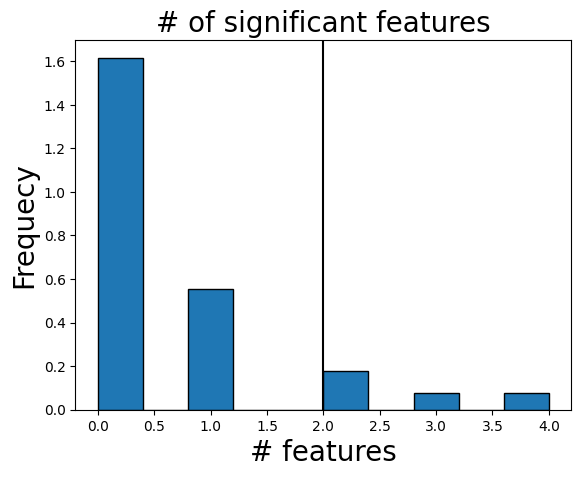

In [114]:
# plt.hist(num_significnat_sums, bins='auto', density=True, edgecolor='black')
# # Set labels and title
# plt.title("# of significant features", fontsize=20)
# plt.xlabel("# features", fontsize=20)
# plt.ylabel("Frequecy", fontsize=20)
# plt.axvline(2,color='black') #=12 (actual number of significant feats at p=0.01)
# # Show plot
# plt.show()

# Sum of correlations

In [ ]:
real_df = pd.read_csv('/tamir2/shaicohen1/CRISPR_MAAGAD/CRISPR_review/code/final_feats/spearman_dfs/df_0.csv')
for i in range(412,1001):
    if i%20==0:
        print(i)
    calc_spearman(i,df_names, all_feats)
print('ALL DONE')

In [ ]:
# Function to merge values
def merge_cells(cell1, cell2):
    if isinstance(cell1, list):
        return cell1 + [cell2]
    else:
        return [cell1, cell2]

In [ ]:
real_df = pd.read_csv('/tamir2/shaicohen1/CRISPR_MAAGAD/CRISPR_review/code/final_feats/spearman_dfs/df_0.csv')
sums_corrs = pd.read_csv(f'./spearman_dfs/df_1.csv')
sums_corrs=sums_corrs[['feature','sum']]
sums_corrs.loc[:,'real_sum'] = real_df['sum']
num_random=400
p_thresh = 0.01
for i in range(2,num_random):
    if i%50==0: print(i)
    curr_df = pd.read_csv(f'./spearman_dfs/df_{i}.csv')
    sums_corrs['sum'] = sums_corrs['sum'].combine(curr_df['sum'], merge_cells)
sums_corrs['p_value'] = sums_corrs.apply(lambda row: sum(x < row['real_sum'] for x in row['sum'])/len(row['sum']), axis=1)
print('any p=0?', np.any(sums_corrs['p_value']==0))
sums_corrs[(sums_corrs['p_value']<p_thresh) | (sums_corrs['p_value']>(1-p_thresh))]

In [ ]:
significant_df = sums_corrs[(sums_corrs['p_value']<p_thresh) | (sums_corrs['p_value']>(1-p_thresh))]
significant_df.loc[significant_df['p_value']>(1-p_thresh),'p_value'] = 1-significant_df.loc[significant_df['p_value']>(1-p_thresh),'p_value']
print(len(significant_df))
significant_df

In [ ]:
num_significnat_sums=[]
for i in range(1,100):
    df = pd.read_csv(f'./spearman_dfs/df_{i}.csv')
    if i%10==0: print(i)
    sums_corrs.loc[:,'rand_sum'] = df['sum']
    df['p_value'] = sums_corrs.apply(lambda row: sum(x < row['rand_sum'] for x in row['sum'])/len(row['sum']), axis=1)
    num_significnat_sums.append(len(df[(df['p_value']<p_thresh) | (sums_corrs['p_value']>(1-p_thresh))]))
print('p thresh:',p_thresh)
print('mean num of significant feats according (randomized sum):', np.mean(num_significnat_sums))
print('actual num of significant feats (sum):', len(significant_df))
print(f"FDR (TAMIR): {len(significant_df)/np.mean(num_significnat_sums):2f}")
print(f"FDR (CHAT): {np.mean(num_significnat_sums)/len(significant_df):2f}")

# binomal p-value

In [183]:
n = 9
k = 7
p = 0.5
# Cumulative probability of getting 7 or more successes
cum_prob = binom.sf(k - 1, n, p)
print(f"P(X ≥ {k}) = {cum_prob:.6f}")
k=8
cum_prob = binom.sf(k - 1, n, p)
print(f"P(X ≥ {k}) = {cum_prob:.6f}")
k=9
cum_prob = binom.sf(k - 1, n, p)
print(f"P(X ≥ {k}) = {cum_prob:.6f}")

P(X ≥ 7) = 0.089844
P(X ≥ 8) = 0.019531
P(X ≥ 9) = 0.001953


In [184]:
num_significants = []
for i in range(1,400):
    df = pd.read_csv(f'./spearman_dfs/dfs_w_sample_make_rep_A_p_values/df_sample_make_rep_A_{i}.csv')
    # getting 8 or more "successes" out of 9 tries is the 1st time it's lower than 0.05
    num_significants.append(len(df[df.num_agreements>=8]))

print('mean of random significants:',np.mean(num_significants))
print('real num of significants: ',len(real_df[real_df.num_agreements>=8]))
print(f'False Discovery Rate: {len(np.mean(num_significants/real_df[real_df.num_agreements>=8])):.2f}')
## Create histogram with frequencies summing to 1
plt.hist(num_significants, bins='auto', density=True, edgecolor='black')
# Set labels and title
plt.title("# of significant features", fontsize=20)
plt.xlabel("# features", fontsize=20)
plt.ylabel("Frequecy", fontsize=20)
plt.axvline(len(real_df[real_df.num_agreements>=8]),color='black') #=7 (actual number of significant feats)
# Show plot
plt.show()

AttributeError: 'DataFrame' object has no attribute 'num_agreements'

# Each creature by itself

In [72]:
# all_spears = pd.read_csv(f'./spearman_dfs/dfs_w_p_values/df_1.csv')
p_thresh = 0.05
num_random=5000
rand_i = 24
concised_names = [x.split('_')[0] for x in df_names]
# all_spears = all_spears.iloc[:,:10]
# for i in range(1,num_random+1):
#     if i%500==0: print(i)
#     curr_df = pd.read_csv(f'./spearman_dfs/dfs_w_p_values/df_{i}.csv')
#     for df_name in concised_names:
#         all_spears[df_name] = all_spears[df_name].combine(curr_df[df_name], merge_cells)
# print('done first part')
real_res = pd.read_csv(f'./spearman_dfs/dfs_w_p_values/df_0.csv')
for df_name in concised_names:
    print(df_name)
    all_spears.loc[:,'actual_' + df_name + '_spear'] = real_res[df_name]
    all_spears.loc[:,'rand_p_' + df_name] = all_spears.apply(lambda row: sum(x < row[df_name][rand_i] for x in row[df_name])/len(row[df_name]), axis=1)
    all_spears.loc[:,'actual_emp_p_'+ df_name] = all_spears.apply(lambda row: sum(x < row['actual_'+df_name+'_spear'] for x in row[df_name])/len(row[df_name]), axis=1)
print('done')

T
ICS
K562
U937
Fly
Shrimp-primary
Shrimp-embryos
Tomato-hairy-roots
Tomato-Protoplasts
done


In [42]:
# df_name='Fly'
# rand_p = len(all_spears[(all_spears['rand_p_' + df_name]<p_thresh) | (all_spears['rand_p_' + df_name]>(1-p_thresh))])
# actual_p = len(all_spears[(all_spears['actual_emp_p_'+ df_name]<p_thresh) | (all_spears['actual_emp_p_'+ df_name]>(1-p_thresh))])
# print(f'any {df_name} p=0',len(all_spears[(all_spears['actual_emp_p_'+ df_name]==0) | (all_spears['actual_emp_p_'+ df_name]==1)]))
# print(f'RANDOM {df_name} significant feats:',rand_p)
# print(f'actual {df_name} significant feats:',actual_p)
# print(f'FDR {rand_p/actual_p :.2f}')

any Fly p=0 0
RANDOM Fly significant feats: 27
actual Fly significant feats: 53
FDR 0.51


In [73]:
significant_standalone = pd.DataFrame({x:[np.nan,np.nan,np.nan] for x in concised_names})
significant_standalone.index = ['sign real','sign RAND','FDR']
significant_standalone['p_thresh'] = p_thresh

In [74]:
for df_name in concised_names:
    rand_p = len(all_spears[(all_spears['rand_p_' + df_name]<p_thresh) | (all_spears['rand_p_' + df_name]>(1-p_thresh))])
    actual_p = len(all_spears[(all_spears['actual_emp_p_'+ df_name]<p_thresh) | (all_spears['actual_emp_p_'+ df_name]>(1-p_thresh))])
    significant_standalone.loc['sign real',df_name] = int(actual_p)
    significant_standalone.loc['sign RAND',df_name] = int(rand_p)
    significant_standalone.loc['FDR',df_name] = rand_p/actual_p

In [75]:
r_24=significant_standalone.copy()

In [76]:
r_24

,T,ICS,K562,U937,Fly,Shrimp-primary,Shrimp-embryos,Tomato-hairy-roots,Tomato-Protoplasts,p_thresh
sign real,48.000,31.000,88.000,36.0,53.000,40.000,38.000,63.000,123.000,0.05
sign RAND,33.000,15.000,127.000,72.0,24.000,99.000,55.000,22.000,44.000,0.05
FDR,0.688,0.484,1.443,2.0,0.453,2.475,1.447,0.349,0.358,0.05


In [62]:
r_231

,T,ICS,K562,U937,Fly,Shrimp-primary,Shrimp-embryos,Tomato-hairy-roots,Tomato-Protoplasts,p_thresh
sign real,48.000,31.000,88.000,36.000,53.000,40.0,38.000,63.000,123.00,0.05
sign RAND,31.000,37.000,68.000,39.000,27.000,44.0,36.000,54.000,32.00,0.05
FDR,0.646,1.194,0.773,1.083,0.509,1.1,0.947,0.857,0.26,0.05


In [71]:
r_4

,T,ICS,K562,U937,Fly,Shrimp-primary,Shrimp-embryos,Tomato-hairy-roots,Tomato-Protoplasts,p_thresh
sign real,48.000,31.000,88.000,36.000,53.000,40.00,38.000,63.000,123.000,0.05
sign RAND,67.000,37.000,42.000,34.000,43.000,54.00,23.000,53.000,70.000,0.05
FDR,1.396,1.194,0.477,0.944,0.811,1.35,0.605,0.841,0.569,0.05


In [78]:
r_423

,T,ICS,K562,U937,Fly,Shrimp-primary,Shrimp-embryos,Tomato-hairy-roots,Tomato-Protoplasts,p_thresh
sign real,48.000,31.000,88.000,36.000,53.000,40.0,38.000,63.000,123.000,0.05
sign RAND,16.000,38.000,57.000,55.000,56.000,36.0,31.000,50.000,21.000,0.05
FDR,0.333,1.226,0.648,1.528,1.057,0.9,0.816,0.794,0.171,0.05
